# Week 3 - Fit of Models

In [151]:
import pandas as pd 
import jax.numpy as jnp
import jax

from src.api.v4 import HMM, GaussEmission, StaticTransition, AutoregressiveGaussEmission, DynamicTransition 
import matplotlib.pyplot as plt

In [152]:
jax.config.update("jax_enable_x64", True)

In [153]:
DATA_PATH = "data/dtu/"

ROOM_FILE = "Room 007"

# rooms to concatenate for the plots below
ROOM_FILES = ["Room 007", "Room 008", "Room 009"]

## Data Exploration

In [154]:
covariates = pd.read_csv(DATA_PATH + "covariates_halfhour.csv", index_col=0)
covariates

,mean_temp,mean_relative_hum,mean_wind_speed,mean_wind_dir,mean_pressure,mean_cloud_cover,mean_radiation,is_holiday,is_weekend,tod_cos,tod_sin
datetime,,,,,,,,,,,
2023-11-01 14:00:00,6.100,73.900,3.80,137.00,1004.100,99.00,98.00,0,0,-0.866025,-5.000000e-01
2023-11-01 14:15:00,6.100,74.925,3.90,135.75,1003.875,97.75,80.90,0,0,-0.866025,-5.000000e-01
2023-11-01 14:30:00,6.100,75.950,4.00,134.50,1003.650,96.50,63.80,0,0,-0.793353,-6.087614e-01
2023-11-01 14:45:00,6.100,76.975,4.10,133.25,1003.425,95.25,46.70,0,0,-0.793353,-6.087614e-01
2023-11-01 15:00:00,6.100,78.000,4.20,132.00,1003.200,94.00,29.60,0,0,-0.707107,-7.071068e-01
...,...,...,...,...,...,...,...,...,...,...,...
2024-02-09 12:00:00,0.200,79.100,5.30,102.00,997.200,100.00,64.80,0,0,-1.000000,1.224647e-16
2024-02-09 12:15:00,0.175,80.450,5.35,102.00,997.050,98.50,62.15,0,0,-1.000000,1.224647e-16
2024-02-09 12:30:00,0.150,81.800,5.40,102.00,996.900,97.00,59.50,0,0,-0.991445,-1.305262e-01


In [155]:
df_room = pd.read_csv(DATA_PATH + "timeseries_halfhour/" + ROOM_FILE + ".csv", index_col=0)
df_room

,co2,temperature,humidity,closed_frac
datetime,,,,
2023-11-01 14:00:00,1770.0,23.1,51.170,1.0
2023-11-01 14:15:00,1675.0,23.2,50.780,NaN
2023-11-01 14:30:00,1609.0,23.2,50.000,1.0
2023-11-01 14:45:00,1500.0,23.2,48.830,NaN
2023-11-01 15:00:00,1561.0,23.2,49.025,1.0
...,...,...,...,...
2024-02-09 12:00:00,1226.5,21.9,41.020,NaN
2024-02-09 12:15:00,1223.0,21.8,41.020,1.0
2024-02-09 12:30:00,1280.5,21.8,41.215,NaN


Loaded 3 rooms, each with 20 days of data.
Start date is: 2023-11-06 00:00:00


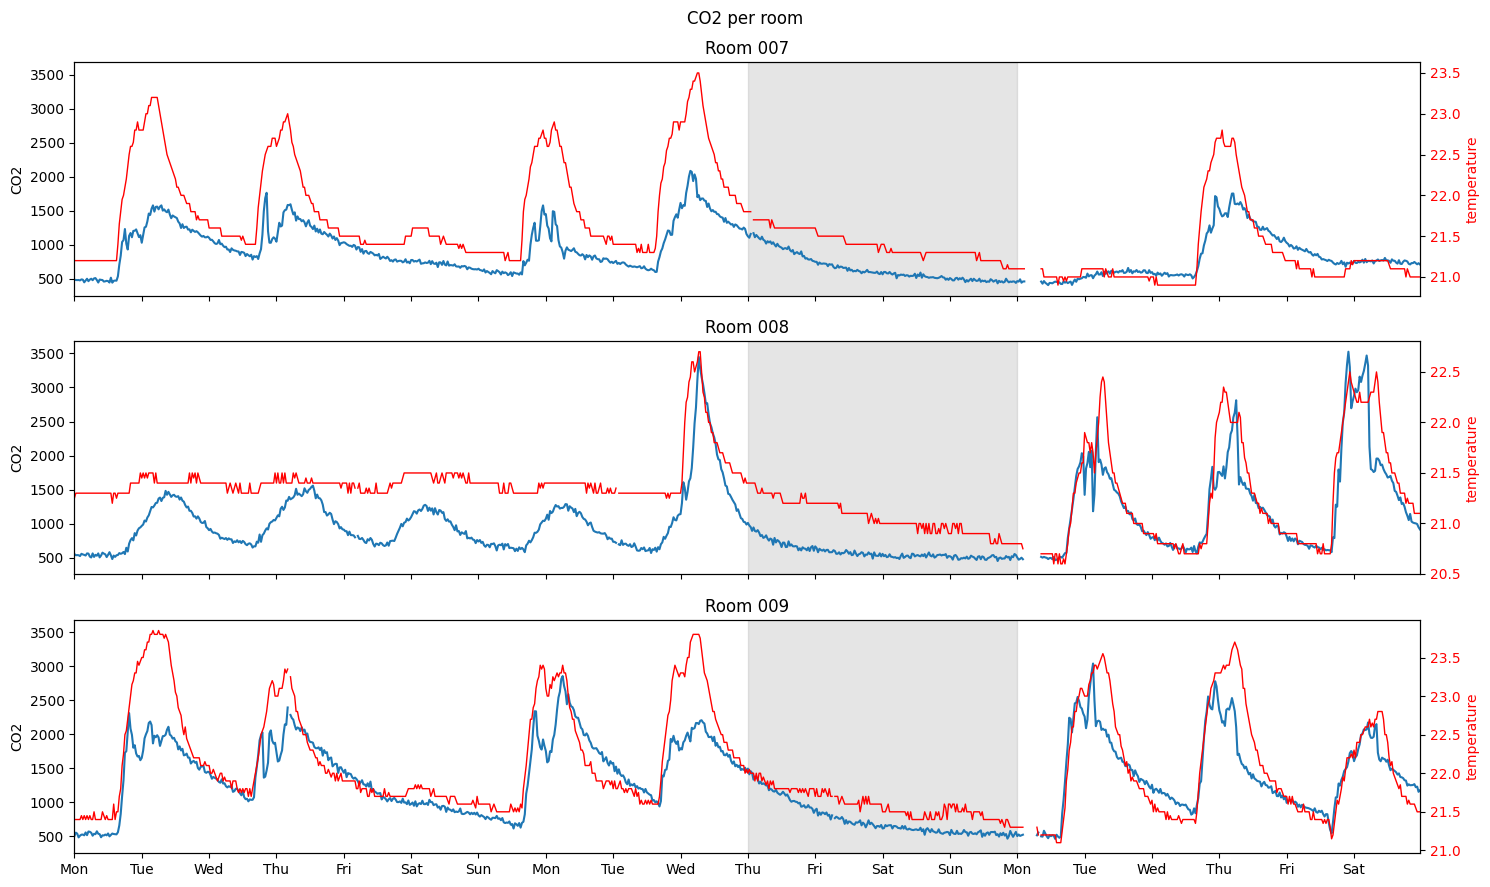

In [156]:
import numpy as np


def load_rooms(room_files, days=None):
    """Load rooms into a dict of frames, each starting on its first Monday."""
    rooms = {}
    for rf in room_files:
        d = pd.read_csv(DATA_PATH + "timeseries_halfhour/" + rf + ".csv", index_col=0)
        d.index = pd.to_datetime(d.index)
        start = int((d.index.weekday == 0).argmax())  # first Monday
        d = d.iloc[start:]
        if days is not None:
            d = d.iloc[:48 * days]
        rooms[rf] = d
    return rooms


def _weekend_spans(mask):
    """Contiguous [start, end) index blocks where mask is True."""
    spans, in_block, s = [], False, 0
    for i, w in enumerate(mask):
        if w and not in_block:
            s, in_block = i, True
        elif not w and in_block:
            spans.append((s, i)); in_block = False
    if in_block:
        spans.append((s, len(mask)))
    return spans


def plot_rooms(rooms, transform=None, ylabel="CO2", suptitle="CO2 per room",
               show_temp=True):
    """One figure with K subplots (one per room), sharing the same axes.
    `transform` optionally maps a room frame -> array of values to plot.
    `show_temp` adds the room temperature on a red secondary y-axis."""
    names = list(rooms)
    K = len(names)
    fig, axes = plt.subplots(K, 1, figsize=(15, 3 * K), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)

    n_max = 0
    for ax, name in zip(axes, names):
        d = rooms[name]
        y = d["co2"].values if transform is None else np.asarray(transform(d))
        x = np.arange(len(d))
        n_max = max(n_max, len(d))

        ax.plot(x, y, label=name)
        dt = pd.to_datetime(d.index)
        for s, e in _weekend_spans(np.asarray(dt.weekday) >= 5):
            ax.axvspan(s, e, color="grey", alpha=0.2)
        ax.set_ylabel(ylabel)
        ax.set_title(name)

        if show_temp:
            ax_t = ax.twinx()
            ax_t.plot(x, d["temperature"].values, color="red", lw=1,
                      label="temperature")
            ax_t.set_ylabel("temperature", color="red")
            ax_t.tick_params(axis="y", labelcolor="red")

    # weekday ticks at each midnight (rooms all start on Monday, so labels align)
    ticks = np.arange(0, n_max + 1, 48)
    monday = pd.Timestamp("2024-01-01")  # a Monday, only used for labels
    labels = [(monday + pd.Timedelta(days=i)).strftime("%a") for i in range(len(ticks))]
    axes[-1].set_xticks(ticks)
    axes[-1].set_xticklabels(labels)
    axes[-1].set_xlim(0, n_max - 1)

    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()


DAYS = 20
rooms = load_rooms(ROOM_FILES, days=DAYS)
print(f"Loaded {len(rooms)} rooms, each with {DAYS} days of data.")
print(f"Start date is: {list(rooms.values())[0].index[0]}")

plot_rooms(rooms)


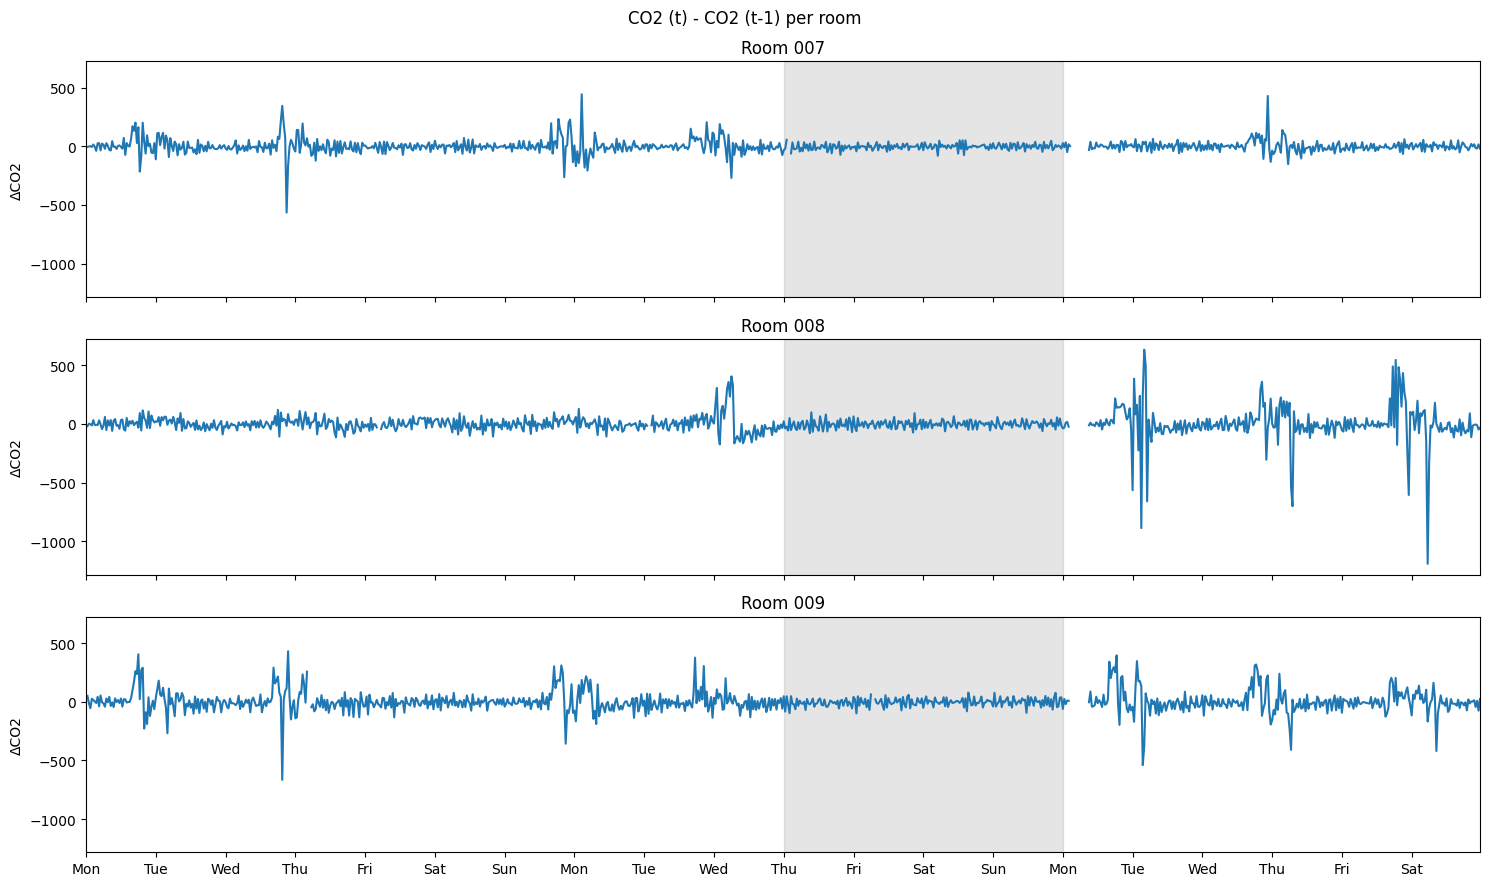

In [157]:
plot_rooms(
    rooms,
    transform=lambda d: d["co2"].diff().values,
    ylabel="ΔCO2",
    suptitle="CO2 (t) - CO2 (t-1) per room",
    show_temp=False,
)


## Finding baseline